# Kappa refinement: temporal organization and connectivity

Follow-up at $\widetilde\kappa=2.5$, $\lambda=1$, $N=1000$, for five densities and four realizations up to $t=1500$.
The goal is to check whether the density-dependent fragmentation persists after the initial transient.

Place this notebook in `preliminar/kappa/refinement/`, beside `processed/` and `ovito/`. Run cells in order.
Dependencies: NumPy, pandas, PyArrow, SciPy, Matplotlib and IPython.

We compare the interaction overlap threshold with 10% and 20% extensions of its directional range, with and without local polar alignment. These are **analysis choices**, not changes to the simulated force or deformation rules. Figures retain individual realizations; time-window averages are not automatically stationary estimates.

## 1. Settings and data validation

The archive contains no launch script. The time conversion and planned output cadence below are explicit inputs; run parameters available in the tables are checked against the intended experiment.

In [1]:
from pathlib import Path
from itertools import product
from functools import lru_cache
import json
import re
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib.lines import Line2D
from scipy.spatial import cKDTree
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

DATA_DIR = Path(".")
PROCESSED_DIR = DATA_DIR / "processed"
SNAPSHOT_DIR = DATA_DIR / "ovito"
FIGURE_DIR = DATA_DIR / "figures"
TABLE_DIR = DATA_DIR / "analysis_tables"
for directory in (FIGURE_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

DELTA_T = 0.05
FINAL_STEP = 30_000
OUTPUT_STEP = 100
FINAL_TIME = FINAL_STEP * DELTA_T
DENSITIES = [0.70, 0.80, 0.84, 0.88, 0.90]
KAPPA = 2.5
LAMBDA_CORE = 1.0
RUN_KEYS = ["lambda_core", "kappa", "rho", "seed"]
TIME_WINDOWS = [(250, 500), (750, 1000), (1250, 1500)]
XI_CUT = np.exp(-1)
XI_SAFE = 0.8
RANGE_FACTORS = [1.0, 1.1, 1.2]
POLAR_ANGLE_DEG = 45.0
# Analyze all saved frames by default. Use a multiple of OUTPUT_STEP for a preview.
CONNECTIVITY_STEP = 100
RECOMPUTE_CONNECTIVITY = False
SAVE_FIGURES = True
SAVE_PDF = False
MAP_DENSITIES = [0.70, 0.84, 0.90]
MAP_STEP = FINAL_STEP

def save_figure(fig, stem):
    if SAVE_FIGURES:
        fig.savefig(FIGURE_DIR / f"{stem}.png", dpi=180, bbox_inches="tight")
        if SAVE_PDF:
            fig.savefig(FIGURE_DIR / f"{stem}.pdf", bbox_inches="tight")

def finish_figure(fig, stem):
    save_figure(fig, stem)
    plt.show()
    plt.close(fig)

In [2]:
tables = {}
for name in ["order_parameters", "motion", "deformation", "overlap"]:
    frame = pd.read_parquet(PROCESSED_DIR / name / f"{name}.parquet")
    frame["time"] = frame["step"] * DELTA_T
    tables[name] = frame.sort_values(RUN_KEYS + ["step"]).reset_index(drop=True)
order_parameters, motion, deformation, overlap = [tables[n] for n in
    ["order_parameters", "motion", "deformation", "overlap"]]
SEEDS = sorted(order_parameters.seed.unique().tolist())
assert len(SEEDS) == 4, "Expected four seeds."
SEED_COLORS = dict(zip(SEEDS, ["tab:blue", "tab:orange", "tab:green", "tab:purple"]))
expected_runs = set(product([LAMBDA_CORE], [KAPPA], DENSITIES, SEEDS))
checks = []
for name, frame in tables.items():
    observed = set(frame[RUN_KEYS].itertuples(index=False, name=None))
    first = 0 if name in ["order_parameters", "motion"] else OUTPUT_STEP
    expected_steps = np.arange(first, FINAL_STEP + 1, OUTPUT_STEP)
    checks.append(dict(dataset=name, runs=len(observed),
        missing_runs=len(expected_runs-observed), unexpected_runs=len(observed-expected_runs),
        duplicates=int(frame.duplicated(RUN_KEYS+["step"]).sum()),
        incomplete_runs=sum(not np.array_equal(g.step.to_numpy(), expected_steps)
                            for _, g in frame.groupby(RUN_KEYS))))
    assert frame.actual_N.eq(1000).all()
checks = pd.DataFrame(checks)
display(checks)
assert checks[["missing_runs", "unexpected_runs", "duplicates", "incomplete_runs"]].eq(0).all().all()
for weighted, raw in [("polar_2", "polar"), ("nematic_2", "nematic")]:
    assert np.allclose(order_parameters[weighted], order_parameters.fraction_elongated * order_parameters[raw], atol=2e-6)
assert overlap.max_normalized_overlap.between(0, 1+1e-10).all()
accepted = deformation.loc[deformation.contraction_events > 0, "max_contraction_accepted_overlap"]
assert accepted.le(XI_SAFE+1e-10).all()
display(pd.DataFrame({"realization": range(1, len(SEEDS)+1), "seed": SEEDS}))

,dataset,runs,missing_runs,unexpected_runs,duplicates,incomplete_runs
0,order_parameters,20,0,0,0,0
1,motion,20,0,0,0,0
2,deformation,20,0,0,0,0
3,overlap,20,0,0,0,0


,realization,seed
0,1,853827592514924
1,2,993068073743470
2,3,1052030010736714
3,4,1099062448631258


In [3]:
pattern = re.compile(r"_density=(?P<rho>[0-9.]+)_force=.*?_k=(?P<kappa>[0-9.]+)_.*?_lambda_core=(?P<lambda_core>[0-9.]+)_.*?_rng_seed=(?P<seed>\d+)\.(?P<step>\d+)$")
snapshot_paths = {}
for path in sorted(SNAPSHOT_DIR.rglob("*")):
    match = pattern.search(path.name) if path.is_file() else None
    if match is None:
        continue
    d = match.groupdict()
    key = (float(d["lambda_core"]), float(d["kappa"]), float(d["rho"]), int(d["seed"]), int(d["step"]))
    if key in snapshot_paths:
        raise ValueError(f"Duplicate snapshot: {key}")
    snapshot_paths[key] = path
expected_snapshots = {(*run, step) for run in expected_runs
                      for step in range(0, FINAL_STEP+1, OUTPUT_STEP)}
assert set(snapshot_paths) == expected_snapshots, (
    f"Missing: {len(expected_snapshots-set(snapshot_paths))}; "
    f"unexpected: {len(set(snapshot_paths)-expected_snapshots)}")
print(f"Validated {len(snapshot_paths)} snapshots across {len(expected_runs)} runs.")

Validated 6020 snapshots across 20 runs.


## 2. Final configurations

Colors encode the full polar angle; round cells are gray. Periodic copies are drawn at box edges. All panels show the complete box, whose physical size changes with density.

In [4]:
from matplotlib.collections import EllipseCollection
from matplotlib.colors import ListedColormap, Normalize, hsv_to_rgb
from matplotlib.patches import Patch

# Orientation colors shared by every figure
hue = np.linspace(0, 1, 1024)
hsv_colors = np.column_stack([
    hue,
    np.full_like(hue, 0.75),
    np.full_like(hue, 0.90),
])

ORIENTATION_CMAP = ListedColormap(
    hsv_to_rgb(hsv_colors),
    name="orientation_hsv",
)
ORIENTATION_NORM = Normalize(0, 2 * np.pi)
ROUND_COLOR = "0.80"


@lru_cache(maxsize=32)
def read_snapshot(path):
    """Read positions, semi-axes, orientations, and box dimensions."""
    with path.open() as stream:
        number_of_cells = int(stream.readline())
        header = stream.readline()


        expected_schema = "Properties=species:S:1:pos:R:3:aspherical_shape:R:3:orientation:R:4:Color:R:1"
        if expected_schema not in header:
            raise ValueError(f"Unexpected OVITO schema: {path}")

        lattice_match = re.search(r'Lattice="([^"]+)"', header)
        if lattice_match is None:
            raise ValueError(f"Missing box dimensions in {path}")

        lattice = np.fromstring(
            lattice_match.group(1),
            sep=" ",
        ).reshape(3, 3)

        values = np.loadtxt(
            stream,
            usecols=range(1, 12),
            ndmin=2,
        )

    if len(values) != number_of_cells:
        raise ValueError(f"Inconsistent cell count in {path}")

    if not np.allclose(lattice, np.diag(np.diag(lattice))):
        raise ValueError(f"Only orthorhombic boxes are supported: {path}")
    box = np.array([lattice[0, 0], lattice[1, 1]])
    if not np.all(box > 0) or not np.isfinite(values).all():
        raise ValueError(f"Invalid box or nonfinite snapshot data: {path}")
    if np.any(values[:, 3:5] <= 0):
        raise ValueError(f"Invalid semi-axes: {path}")

    # Planar rotations are stored as quaternions (x, y, z, w)
    phi = np.mod(
        2 * np.arctan2(values[:, 8], values[:, 9]),
        2 * np.pi,
    )

    return {
        "positions": values[:, :2] % box,
        "major": values[:, 3],
        "minor": values[:, 4],
        "phi": phi,
        "box": box,
    }


def draw_snapshot(ax, snapshot, facecolors=None, annotation=None):
    """Draw one configuration, including periodic boundary copies."""
    positions = snapshot["positions"]
    major = snapshot["major"]
    minor = snapshot["minor"]
    phi = snapshot["phi"]
    box = snapshot["box"]

    is_round = np.isclose(major / minor, 1.0)

    colors = ORIENTATION_CMAP(ORIENTATION_NORM(phi))
    colors[is_round] = plt.matplotlib.colors.to_rgba(ROUND_COLOR)
    if facecolors is not None:
        colors = np.asarray(facecolors)

    # Bounding-box half-widths of each rotated ellipse
    extent_x = np.sqrt(
        (major * np.cos(phi))**2
        + (minor * np.sin(phi))**2
    )
    extent_y = np.sqrt(
        (major * np.sin(phi))**2
        + (minor * np.cos(phi))**2
    )

    for shift_x, shift_y in product(
        [-box[0], 0, box[0]],
        [-box[1], 0, box[1]],
    ):
        shifted = positions + np.array([shift_x, shift_y])

        visible = (
            (shifted[:, 0] + extent_x >= 0)
            & (shifted[:, 0] - extent_x <= box[0])
            & (shifted[:, 1] + extent_y >= 0)
            & (shifted[:, 1] - extent_y <= box[1])
        )

        if not visible.any():
            continue

        collection = EllipseCollection(
            widths=2 * major[visible],
            heights=2 * minor[visible],
            angles=np.degrees(phi[visible]),
            units="xy",
            offsets=shifted[visible],
            transOffset=ax.transData,
            facecolors=colors[visible],
            edgecolors="0.25",
            linewidths=0.20,
            rasterized=True,
        )
        ax.add_collection(collection)

    ax.set(
        xlim=(0, box[0]),
        ylim=(0, box[1]),
        aspect="equal",
        xticks=[],
        yticks=[],
    )

    ax.text(
        0.03,
        0.97,
        (rf"$f_E={np.mean(~is_round):.2f}$" if annotation is None else annotation),
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.8,
            "pad": 1.5,
        },
    )


def add_orientation_wheel(fig):
    """Add a circular legend using the same orientation mapping."""
    ax = fig.add_axes(
        [0.875, 0.90, 0.065, 0.065],
        projection="polar",
    )

    theta_edges = np.linspace(0, 2 * np.pi, 721)
    theta_centers = (
        theta_edges[:-1] + theta_edges[1:]
    ) / 2

    ax.pcolormesh(
        theta_edges,
        [0, 1],
        theta_centers[None, :],
        cmap=ORIENTATION_CMAP,
        norm=ORIENTATION_NORM,
        shading="flat",
        rasterized=True,
    )

    ax.set_theta_zero_location("E")
    ax.set_theta_direction(1)
    ax.set_xticks(
        [0, np.pi / 2, np.pi, 3 * np.pi / 2],
        labels=[r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$"],
    )
    ax.set_yticks([])
    ax.set_ylim(0, 1)
    ax.grid(False)
    ax.tick_params(axis="x", labelsize=8, pad=0)
    ax.spines["polar"].set_linewidth(0.8)

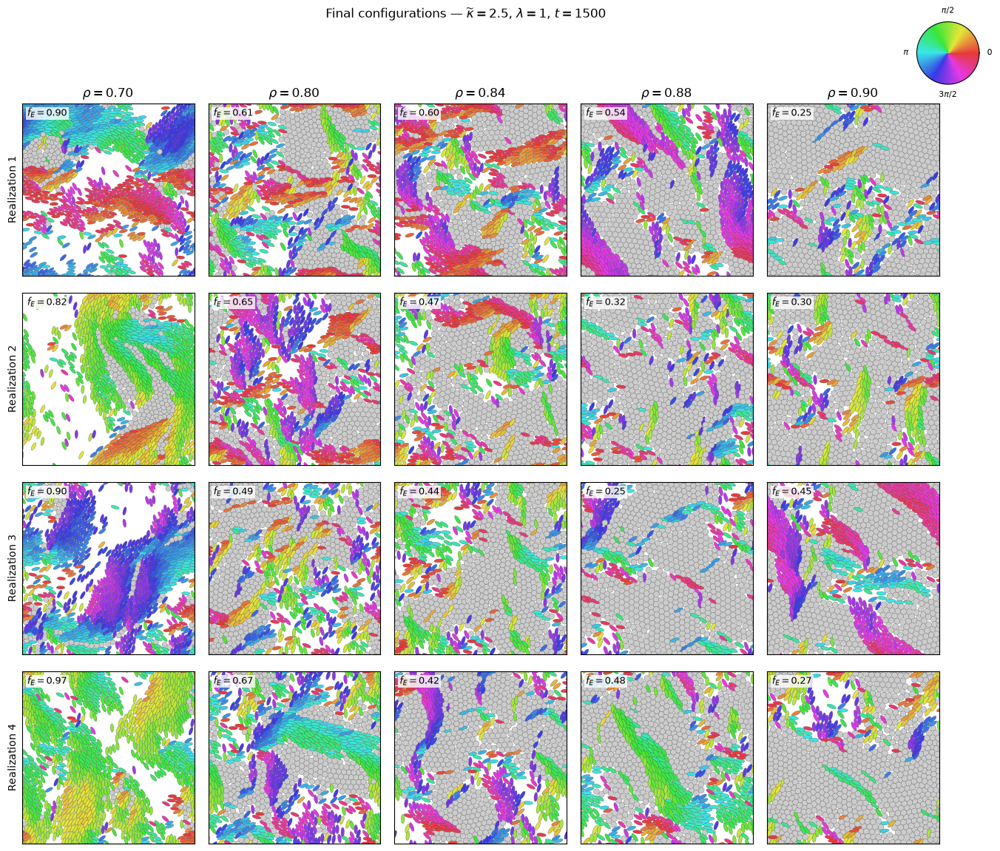

In [5]:
fig, axes = plt.subplots(len(SEEDS), len(DENSITIES), figsize=(16, 13), squeeze=False)
for row, seed in enumerate(SEEDS):
    for col, rho in enumerate(DENSITIES):
        snapshot = read_snapshot(snapshot_paths[(LAMBDA_CORE, KAPPA, rho, seed, FINAL_STEP)])
        draw_snapshot(axes[row, col], snapshot)
        if row == 0:
            axes[row, col].set_title(rf"$\rho={rho:.2f}$")
        if col == 0:
            axes[row, col].set_ylabel(f"Realization {row+1}")
fig.suptitle(rf"Final configurations — $\widetilde\kappa={KAPPA}$, $\lambda={LAMBDA_CORE:g}$, $t={FINAL_TIME:g}$", y=.98)
fig.subplots_adjust(top=.88, hspace=.10, wspace=.08)
add_orientation_wheel(fig)
finish_figure(fig, "01_final_configurations")

## 3. Temporal diagnostics

Each color identifies one realization. Read $f_E$, unweighted $P_E,Q_E$, and their weighted counterparts together. Unweighted order is undefined when no elongates remain and is masked. High order in a tiny population is not evidence of collective organization.

Motion is shown as the mean one-step displacement divided by $\Delta t$, not as a noise-independent instantaneous velocity. The overlap observable is the maximum over an output interval, not a pair average. The contraction threshold does not bound overlaps produced by subsequent motion.

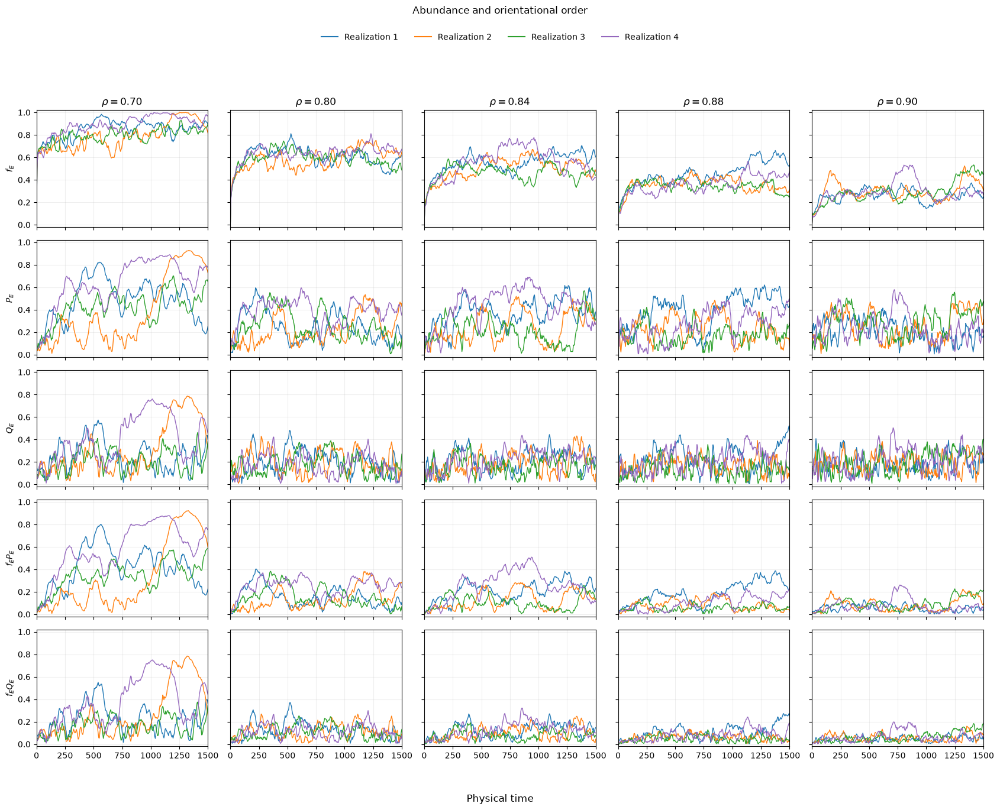

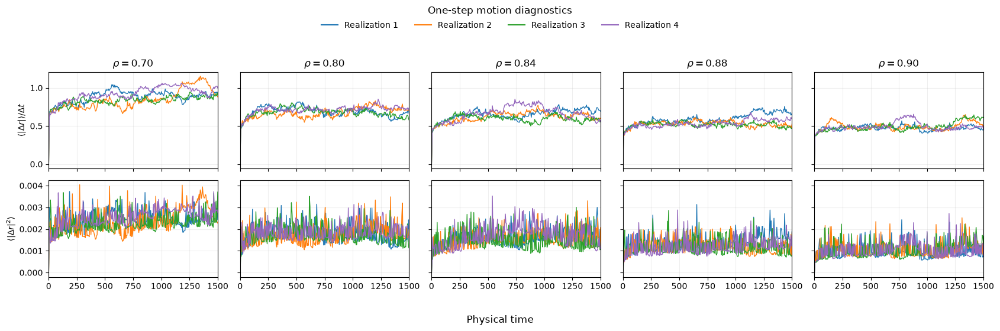

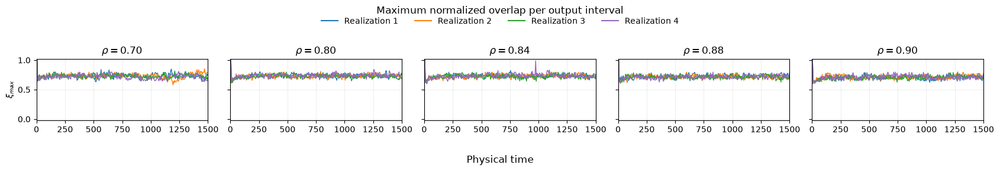

In [6]:
def time_panels(frame, specs, stem, title, bounded=False):
    fig, axes = plt.subplots(len(specs), len(DENSITIES), figsize=(17, 2.7*len(specs)), squeeze=False, sharex=True, sharey="row")
    for row, (column, label) in enumerate(specs):
        for col, rho in enumerate(DENSITIES):
            ax = axes[row, col]
            for seed in SEEDS:
                g = frame.loc[np.isclose(frame.rho, rho) & frame.seed.eq(seed)].sort_values("time")
                ax.plot(g.time, g[column], color=SEED_COLORS[seed], lw=1)
            if row == 0:
                ax.set_title(rf"$\rho={rho:.2f}$")
            if col == 0:
                ax.set_ylabel(label)
            if bounded:
                ax.set_ylim(-.02, 1.02)
            ax.set_xlim(0, FINAL_TIME)
            ax.grid(alpha=.2)
    fig.suptitle(title, y=1.01)
    fig.legend(handles=[Line2D([0], [0], color=SEED_COLORS[s], label=f"Realization {i+1}")
                        for i,s in enumerate(SEEDS)], loc="upper center", bbox_to_anchor=(.5,.985), ncol=4, frameon=False)
    fig.supxlabel("Physical time")
    fig.tight_layout(rect=(0,.03,1,.93))
    finish_figure(fig, stem)

order = order_parameters.copy()
order.loc[order.fraction_elongated.eq(0), ["polar", "nematic"]] = np.nan
time_panels(order, [("fraction_elongated", r"$f_E$"), ("polar", r"$P_E$"), ("nematic", r"$Q_E$"),
                    ("polar_2", r"$f_EP_E$"), ("nematic_2", r"$f_EQ_E$")],
            "02_order_timeseries", "Abundance and orientational order", bounded=True)
motion["mean_step_rate"] = motion.mean_step_displacement / DELTA_T
time_panels(motion, [("mean_step_rate", r"$\langle|\Delta r|\rangle/\Delta t$"),
                     ("mean_squared_step_displacement", r"$\langle|\Delta r|^2\rangle$")],
            "03_motion_timeseries", "One-step motion diagnostics")
time_panels(overlap, [("max_normalized_overlap", r"$\xi_{max}$")],
            "04_overlap_timeseries", "Maximum normalized overlap per output interval", bounded=True)

## 4. Density dependence across time windows

Compute one mean per realization in each interval `start < t <= end`. Points remain paired by seed across densities. These windows diagnose drift; temporal samples are correlated and are not treated as independent realizations. Counts are exported so missing or undefined observations remain visible.

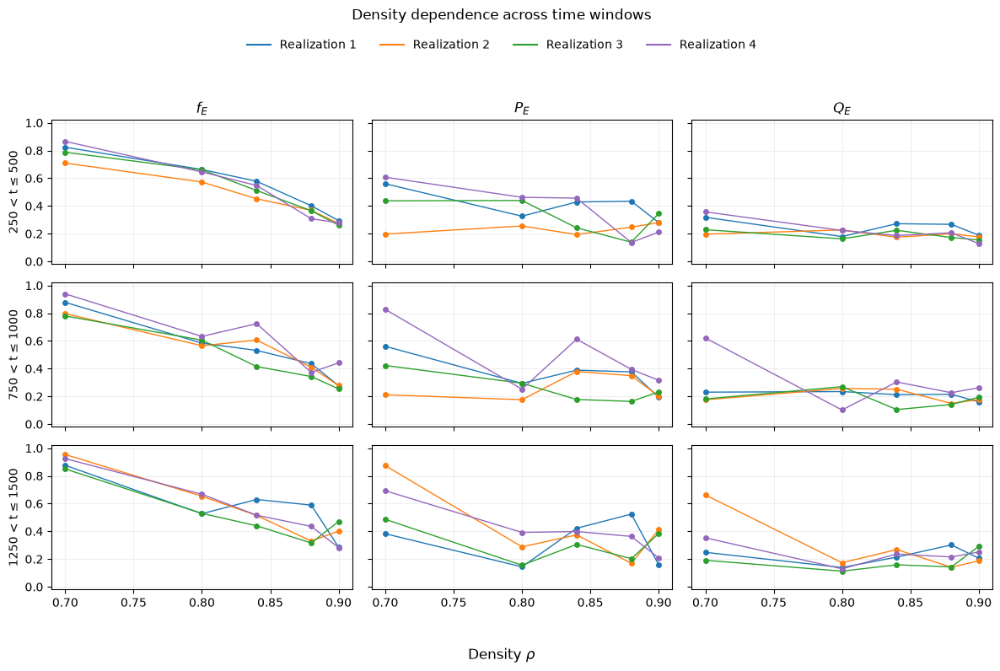

In [7]:
def window_means(frame, columns, extra_keys=()):
    keys = RUN_KEYS + list(extra_keys)
    records = []
    for start, end in TIME_WINDOWS:
        part = frame.loc[(frame.time > start) & (frame.time <= end)]
        means = part.groupby(keys, as_index=False)[columns].mean()
        counts = part.groupby(keys)[columns].count().add_prefix("n_valid_").reset_index()
        means = means.merge(counts, on=keys, validate="one_to_one")
        means["time_start"], means["time_end"] = start, end
        records.append(means)
    return pd.concat(records, ignore_index=True)

def density_panels(summary, specs, stem, title, selector=None):
    fig, axes = plt.subplots(len(TIME_WINDOWS), len(specs), figsize=(4*len(specs), 8), squeeze=False, sharex=True, sharey=True)
    for row, (start, end) in enumerate(TIME_WINDOWS):
        subset = summary.loc[summary.time_start.eq(start) & summary.time_end.eq(end)]
        if selector is not None:
            subset = selector(subset)
        for col, (column, label) in enumerate(specs):
            ax=axes[row,col]
            for seed in SEEDS:
                g=subset.loc[subset.seed.eq(seed)].sort_values("rho")
                ax.plot(g.rho,g[column],"o-",color=SEED_COLORS[seed],ms=4,lw=1)
            if row==0: ax.set_title(label)
            if col==0: ax.set_ylabel(f"{start} < t ≤ {end}")
            ax.set_ylim(-.02,1.02); ax.grid(alpha=.2)
    fig.suptitle(title)
    fig.legend(handles=[Line2D([0],[0],color=SEED_COLORS[s],label=f"Realization {i+1}") for i,s in enumerate(SEEDS)], loc="upper center",bbox_to_anchor=(.5,.95),ncol=4,frameon=False)
    fig.supxlabel(r"Density $\rho$")
    fig.tight_layout(rect=(0,.03,1,.90))
    finish_figure(fig,stem)

order["n_elongated"] = order.fraction_elongated * order.actual_N
order_windows = window_means(order, ["fraction_elongated", "polar", "nematic", "polar_2", "nematic_2", "n_elongated"])
density_panels(order_windows, [("fraction_elongated",r"$f_E$"),("polar",r"$P_E$"),("nematic",r"$Q_E$")],
               "05_order_windows", "Density dependence across time windows")

## 5. Time-dependent connectivity

Only elongated cells are vertices; round cells cannot bridge components. Isolates count as components of size one.
For semi-axis shape matrices $B_i=\mathcal R(\phi_i)\operatorname{diag}(a_i^2,b_i^2)\mathcal R(\phi_i)^T$,
$$\xi_{ij}=\exp[-\tfrac12\mathbf r_{ij}^T(B_i+B_j)^{-1}\mathbf r_{ij}].$$
Minimum-image displacements are used in the periodic box. For a fixed shape and direction, $\xi(r)=e^{-qr^2}$.
A range factor $b$ therefore gives $\xi_{\mathrm{cluster}}=(\xi_{\mathrm{cut}})^{b^2}=e^{-b^2}$:

| Range extension | Threshold |
|---|---|
| 0% | 0.367879 |
| 10% | 0.298197 |
| 20% | 0.236928 |

This extends the **interaction-threshold range**, not necessarily geometric contact distance.
For each threshold we also require, in a separate graph, $\cos(\phi_i-\phi_j)\ge\cos45^\circ$.
Local polar alignment excludes antiparallel neighbors, but a connected component may curve and need not have high global polarization.

$$C_E=S_{\max,E}/N_E,\qquad G_E=S_{\max,E}/N=f_E C_E.$$
For $N_E=0$, $C_E$ is undefined and $G_E=0$. Connectivity alone does not establish periodic wrapping or a thermodynamic phase transition.

A single periodic KD-tree search covers the most permissive threshold. Pair overlaps are evaluated once per frame and reused for all six graphs. Results are cached with settings and input-file size/modification-time signatures; set `RECOMPUTE_CONNECTIVITY=True` to force a rebuild.

In [8]:
def normalized_pair_overlap(major, minor, phi, pairs, displacements):
    """Evaluate normalized Gaussian overlap for the supplied pairs."""
    cosine = np.cos(phi)
    sine = np.sin(phi)

    # Shape matrix B = rotation @ diag(major², minor²) @ rotation.T
    bxx = major**2 * cosine**2 + minor**2 * sine**2
    byy = major**2 * sine**2 + minor**2 * cosine**2
    bxy = (major**2 - minor**2) * cosine * sine

    i, j = pairs.T

    # Normalized overlap: exp[-r.T @ inv(B_i + B_j) @ r / 2]
    sxx = bxx[i] + bxx[j]
    syy = byy[i] + byy[j]
    sxy = bxy[i] + bxy[j]
    determinant = sxx * syy - sxy**2

    dx, dy = displacements.T
    exponent = 0.5 * (
        syy * dx**2
        - 2 * sxy * dx * dy
        + sxx * dy**2
    ) / determinant

    return np.exp(-exponent)


def summarize_components(phi, pairs, total_cells):
    """Summarize an undirected graph, including isolated elongated cells."""
    n_elongated = len(phi)

    if n_elongated == 0:
        return {
            "n_elongated": 0,
            "fraction_elongated": 0.0,
            "n_edges": 0,
            "n_components": 0,
            "largest_size": 0,
            "C_E": np.nan,
            "G_E": 0.0,
        }, [], np.empty(0, dtype=int)

    graph = coo_matrix(
        (
            np.ones(len(pairs)),
            (pairs[:, 0], pairs[:, 1]),
        ),
        shape=(n_elongated, n_elongated),
    ).tocsr()

    n_components, labels = connected_components(
        graph,
        directed=False,
    )

    sizes = np.bincount(labels, minlength=n_components)

    polar = np.hypot(
        np.bincount(labels, weights=np.cos(phi)),
        np.bincount(labels, weights=np.sin(phi)),
    ) / sizes

    nematic = np.hypot(
        np.bincount(labels, weights=np.cos(2 * phi)),
        np.bincount(labels, weights=np.sin(2 * phi)),
    ) / sizes

    largest = int(sizes.max())

    summary = {
        "n_elongated": n_elongated,
        "fraction_elongated": n_elongated / total_cells,
        "n_edges": len(pairs),
        "n_components": n_components,
        "largest_size": largest,
        "C_E": largest / n_elongated,
        "G_E": largest / total_cells,
    }

    components = [
        {
            "component_id": index,
            "size": int(size),
            "polar": float(polar[index]),
            "nematic": float(nematic[index]),
            "is_largest": bool(size == largest),
        }
        for index, size in enumerate(sizes)
    ]

    return summary, components, labels

In [9]:
def analyze_connectivity(snapshot, with_labels=False):
    mask = ~np.isclose(snapshot["major"] / snapshot["minor"], 1.0)
    positions = snapshot["positions"][mask]
    major, minor, phi = [snapshot[n][mask] for n in ("major", "minor", "phi")]
    box = snapshot["box"]
    pairs = np.empty((0,2),dtype=int)
    xi = np.empty(0)
    aligned = np.empty(0,dtype=bool)
    if len(phi)>1:
        # Conservative bound, including all orientations at the lowest threshold.
        search_radius = 2*major.max()*max(RANGE_FACTORS)*np.sqrt(-np.log(XI_CUT))
        pairs = cKDTree(positions, boxsize=box).query_pairs(search_radius,output_type="ndarray")
        dr=positions[pairs[:,1]]-positions[pairs[:,0]]
        dr-=box*np.rint(dr/box)
        xi=normalized_pair_overlap(major,minor,phi,pairs,dr)
        aligned=np.cos(phi[pairs[:,0]]-phi[pairs[:,1]]) >= np.cos(np.deg2rad(POLAR_ANGLE_DEG))
    records, labels_out = [], {}
    for factor in RANGE_FACTORS:
        threshold = XI_CUT**(factor**2)
        for polar_filter in (False,True):
            selected=(xi>threshold) & (aligned if polar_filter else True)
            summary, _, labels=summarize_components(phi,pairs[selected],len(mask))
            records.append(dict(range_factor=factor,xi_threshold=threshold,
                                polar_filter=polar_filter,polar_angle_deg=POLAR_ANGLE_DEG,**summary))
            if with_labels:
                full=np.full(len(mask),-1,dtype=int);full[mask]=labels
                labels_out[(factor,polar_filter)]=full
    return records, labels_out

assert CONNECTIVITY_STEP >= OUTPUT_STEP and CONNECTIVITY_STEP % OUTPUT_STEP == 0
assert 0 < XI_CUT < 1 and min(RANGE_FACTORS) >= 1
selected_paths = {key:p for key,p in snapshot_paths.items() if key[-1] % CONNECTIVITY_STEP == 0}
settings = dict(algorithm_version=1, delta_t=DELTA_T, final_step=FINAL_STEP,
                xi_cut=float(XI_CUT), range_factors=RANGE_FACTORS, polar_angle_deg=POLAR_ANGLE_DEG,
                connectivity_step=CONNECTIVITY_STEP)
manifest = [(list(k),p.name,p.stat().st_size,p.stat().st_mtime_ns) for k,p in sorted(selected_paths.items())]
signature = hashlib.sha256(json.dumps(dict(settings=settings,files=manifest),sort_keys=True).encode()).hexdigest()
cache_path = TABLE_DIR / "connectivity_timeseries.parquet"
cache_meta = TABLE_DIR / "connectivity_cache.json"
cache_ok = (cache_path.exists() and cache_meta.exists()
            and json.loads(cache_meta.read_text()).get("signature")==signature)
if cache_ok and not RECOMPUTE_CONNECTIVITY:
    connectivity = pd.read_parquet(cache_path)
    print("Loaded matching connectivity cache.")
else:
    rows=[]
    phenotype = order_parameters.set_index(RUN_KEYS+["step"])["fraction_elongated"]
    for index,(key,path) in enumerate(sorted(selected_paths.items()),start=1):
        snap=read_snapshot(path)
        observed=np.mean(~np.isclose(snap["major"]/snap["minor"],1.0))
        assert np.isclose(observed,phenotype.loc[key],atol=2e-6), f"Phenotype mismatch: {key}"
        records,_=analyze_connectivity(snap)
        metadata=dict(zip(RUN_KEYS+["step"],key));metadata["time"]=key[-1]*DELTA_T
        rows.extend({**metadata,**r} for r in records)
        if index%500==0 or index==len(selected_paths):
            print(f"Connectivity: {index}/{len(selected_paths)} frames",flush=True)
    connectivity=pd.DataFrame(rows)
    connectivity.to_parquet(cache_path,index=False)
    cache_meta.write_text(json.dumps(dict(signature=signature,settings=settings),indent=2))

keys=RUN_KEYS+["step","range_factor","polar_filter"]
assert not connectivity.duplicated(keys).any()
assert len(connectivity)==len(selected_paths)*len(RANGE_FACTORS)*2
assert np.allclose(connectivity.G_E,connectivity.fraction_elongated*connectivity.C_E.fillna(0))
assert connectivity.largest_size.le(connectivity.n_elongated).all()
pivot=connectivity.pivot(index=RUN_KEYS+["step","range_factor"],columns="polar_filter",values="largest_size")
assert (pivot[True]<=pivot[False]).all()
monotone=connectivity.pivot(index=RUN_KEYS+["step","polar_filter"],columns="range_factor",values="largest_size")
assert (np.diff(monotone.sort_index(axis=1).to_numpy(),axis=1)>=0).all()
print(f"Validated {len(connectivity)} connectivity summaries.")

Connectivity: 500/6020 frames
Connectivity: 1000/6020 frames
Connectivity: 1500/6020 frames
Connectivity: 2000/6020 frames
Connectivity: 2500/6020 frames
Connectivity: 3000/6020 frames
Connectivity: 3500/6020 frames
Connectivity: 4000/6020 frames
Connectivity: 4500/6020 frames
Connectivity: 5000/6020 frames
Connectivity: 5500/6020 frames
Connectivity: 6000/6020 frames
Connectivity: 6020/6020 frames
Validated 36120 connectivity summaries.


## 6. Connectivity trajectories and window averages

Each figure compares the same four realizations across densities and range extensions. Compare both normalizations: a decline in $G_E$ may reflect fewer elongates, while $C_E$ measures the fraction of the remaining elongates in the largest component. Changing their abundance can still change graph connectivity, even after this normalization.

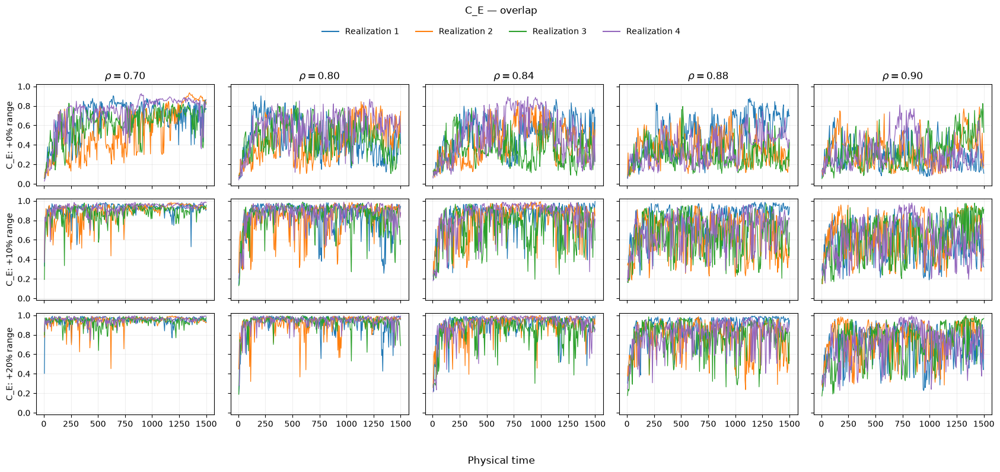

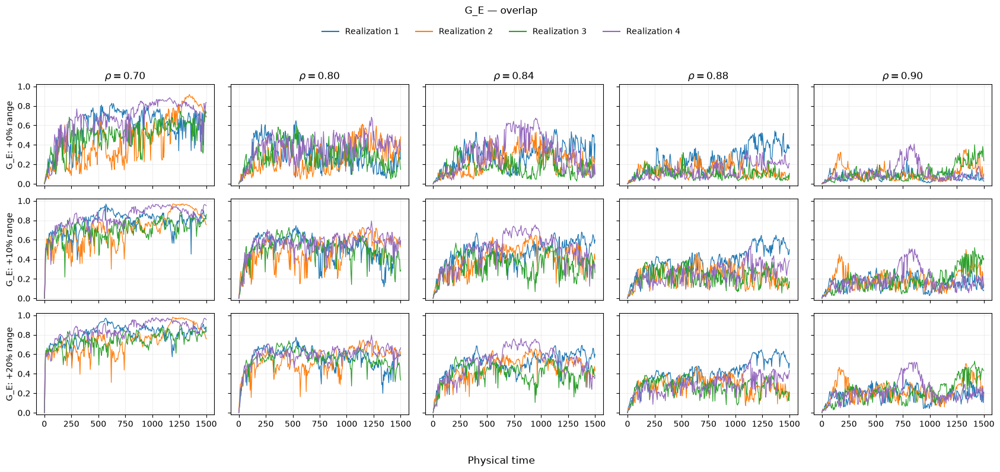

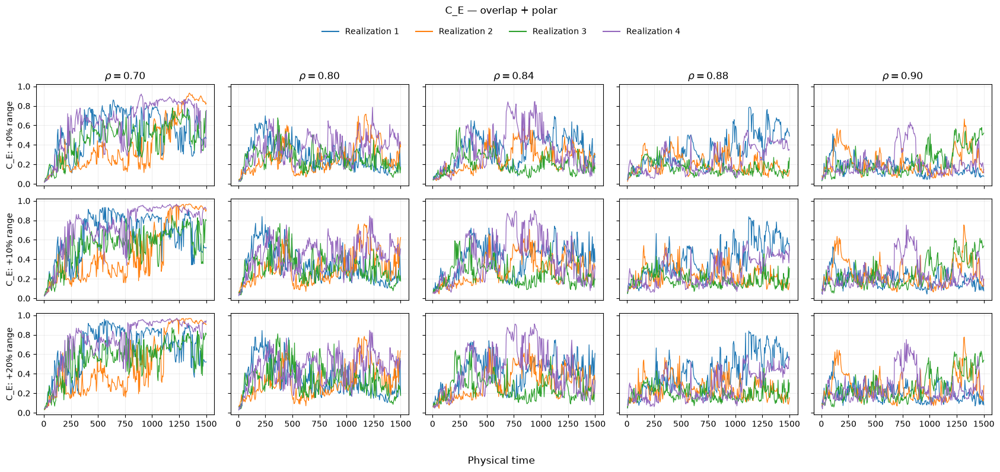

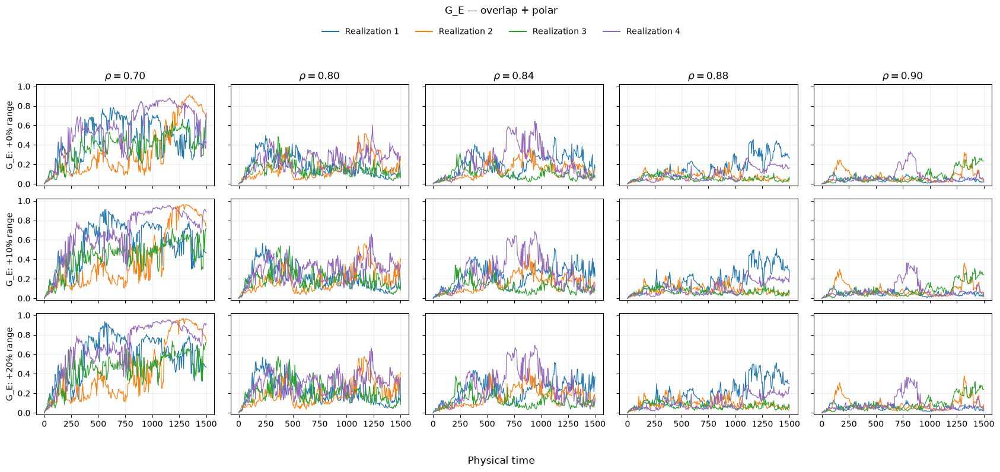

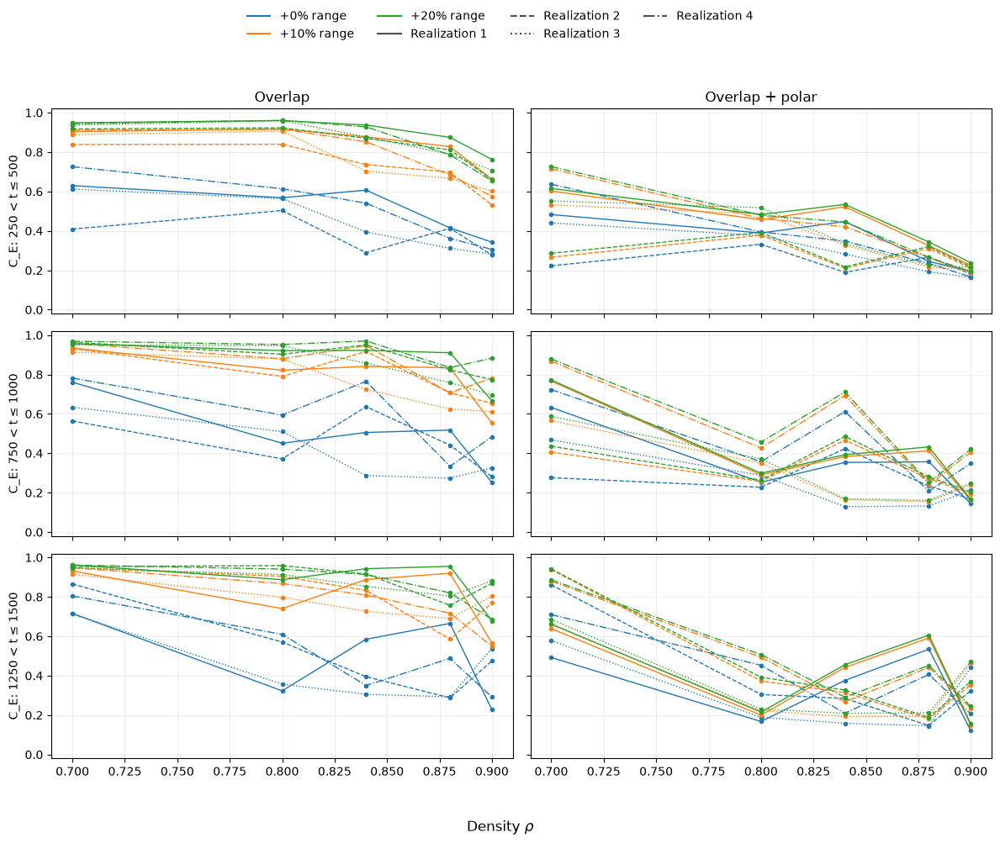

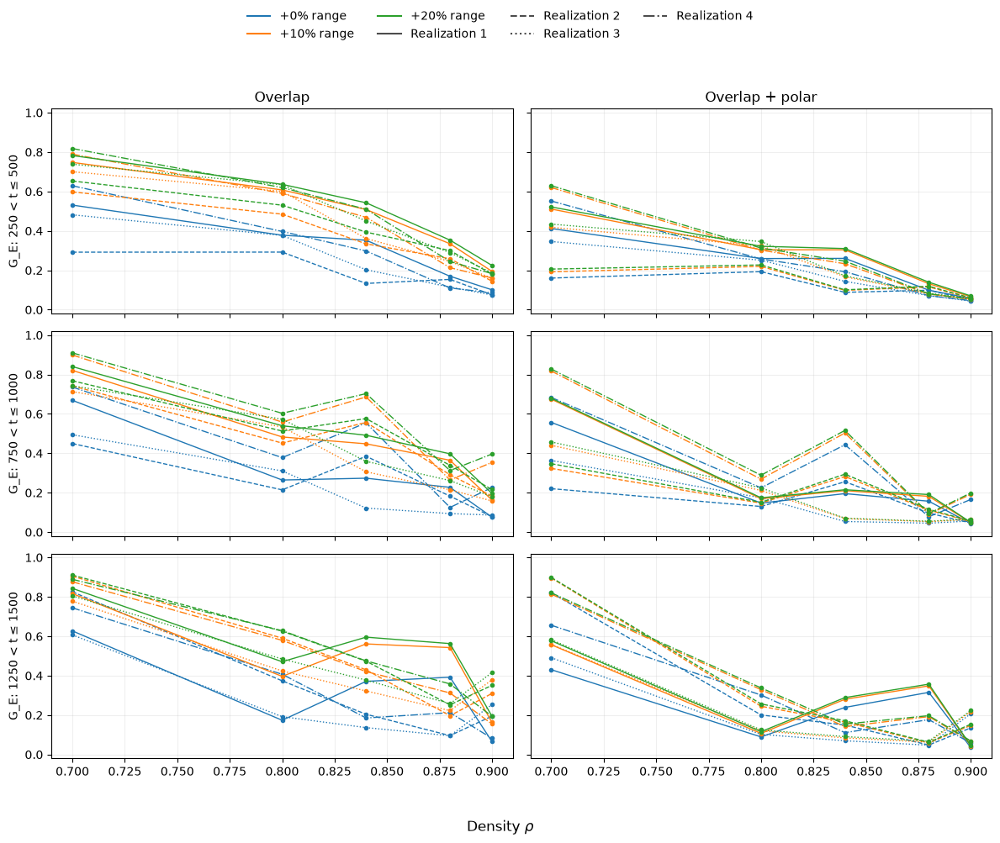

In [10]:
for polar_filter in (False,True):
    label = "overlap_polar" if polar_filter else "overlap"
    for metric in ("C_E","G_E"):
        fig,axes=plt.subplots(len(RANGE_FACTORS),len(DENSITIES),figsize=(17,8),squeeze=False,sharex=True,sharey=True)
        for row,factor in enumerate(RANGE_FACTORS):
            for col,rho in enumerate(DENSITIES):
                ax=axes[row,col]
                for seed in SEEDS:
                    g=connectivity.loc[connectivity.polar_filter.eq(polar_filter)&np.isclose(connectivity.range_factor,factor)&np.isclose(connectivity.rho,rho)&connectivity.seed.eq(seed)].sort_values("time")
                    ax.plot(g.time,g[metric],color=SEED_COLORS[seed],lw=.9)
                if row==0: ax.set_title(rf"$\rho={rho:.2f}$")
                if col==0: ax.set_ylabel(f"{metric}: +{100*(factor-1):.0f}% range")
                ax.set_ylim(-.02,1.02);ax.grid(alpha=.2)
        fig.suptitle(f"{metric} — {label.replace('_',' + ')}")
        fig.legend(handles=[Line2D([0],[0],color=SEED_COLORS[s],label=f"Realization {i+1}") for i,s in enumerate(SEEDS)],loc="upper center",bbox_to_anchor=(.5,.95),ncol=4,frameon=False)
        fig.supxlabel("Physical time");fig.tight_layout(rect=(0,.03,1,.90))
        finish_figure(fig,f"06_{label}_{metric}_timeseries")

connectivity_windows=window_means(connectivity,["C_E","G_E","fraction_elongated","n_elongated","largest_size","n_components"],
                                 extra_keys=["range_factor","polar_filter","xi_threshold","polar_angle_deg"])
for metric in ("C_E","G_E"):
    fig,axes=plt.subplots(len(TIME_WINDOWS),2,figsize=(12,10),squeeze=False,sharex=True,sharey=True)
    colors={1.0:"tab:blue",1.1:"tab:orange",1.2:"tab:green"}
    styles=dict(zip(SEEDS,["-","--",":","-."]))
    for row,(start,end) in enumerate(TIME_WINDOWS):
        for col,polar_filter in enumerate((False,True)):
            ax=axes[row,col]
            for factor,seed in product(RANGE_FACTORS,SEEDS):
                g=connectivity_windows.loc[connectivity_windows.time_start.eq(start)&connectivity_windows.time_end.eq(end)&connectivity_windows.polar_filter.eq(polar_filter)&np.isclose(connectivity_windows.range_factor,factor)&connectivity_windows.seed.eq(seed)].sort_values("rho")
                ax.plot(g.rho,g[metric],marker="o",ms=3,color=colors[factor],ls=styles[seed],lw=1)
            if row==0:ax.set_title("Overlap + polar" if polar_filter else "Overlap")
            if col==0:ax.set_ylabel(f"{metric}: {start} < t ≤ {end}")
            ax.set_ylim(-.02,1.02);ax.grid(alpha=.2)
    handles=[Line2D([0],[0],color=colors[b],label=f"+{100*(b-1):.0f}% range") for b in RANGE_FACTORS]
    handles += [Line2D([0],[0],color=".3",ls=styles[s],label=f"Realization {i+1}") for i,s in enumerate(SEEDS)]
    fig.legend(handles=handles,loc="upper center",ncol=4,frameon=False)
    fig.supxlabel(r"Density $\rho$");fig.tight_layout(rect=(0,.03,1,.91))
    finish_figure(fig,f"07_{metric}_windows_and_thresholds")

## 7. Component maps

For each seed, compare the three thresholds with and without the polar filter. Colors rank components by size **within each panel**; they do not track identity between panels or times. All minor components share a pale color; they are not one connected group. Change `MAP_STEP` to inspect an earlier saved configuration.

In [11]:
COMPONENT_COLORS = ["#3979B5", "#E58A36", "#4F9A69", "#9567A5", "#997253"]
SMALL_COMPONENT_COLOR = "#CBDCE8"


def component_facecolors(labels):
    colors = np.tile(plt.matplotlib.colors.to_rgba(ROUND_COLOR), (len(labels), 1))
    elongated = labels >= 0
    colors[elongated] = plt.matplotlib.colors.to_rgba(SMALL_COMPONENT_COLOR)
    if elongated.any():
        sizes = np.bincount(labels[elongated])
        ranked = np.argsort(-sizes, kind="stable")
        for component, color in zip(ranked, COMPONENT_COLORS):
            colors[labels == component] = plt.matplotlib.colors.to_rgba(color)
    return colors

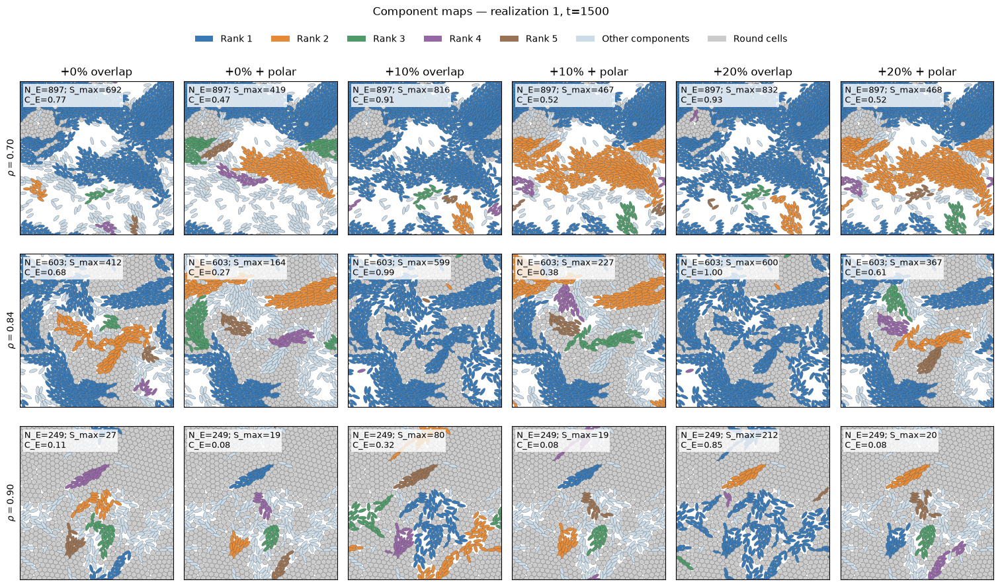

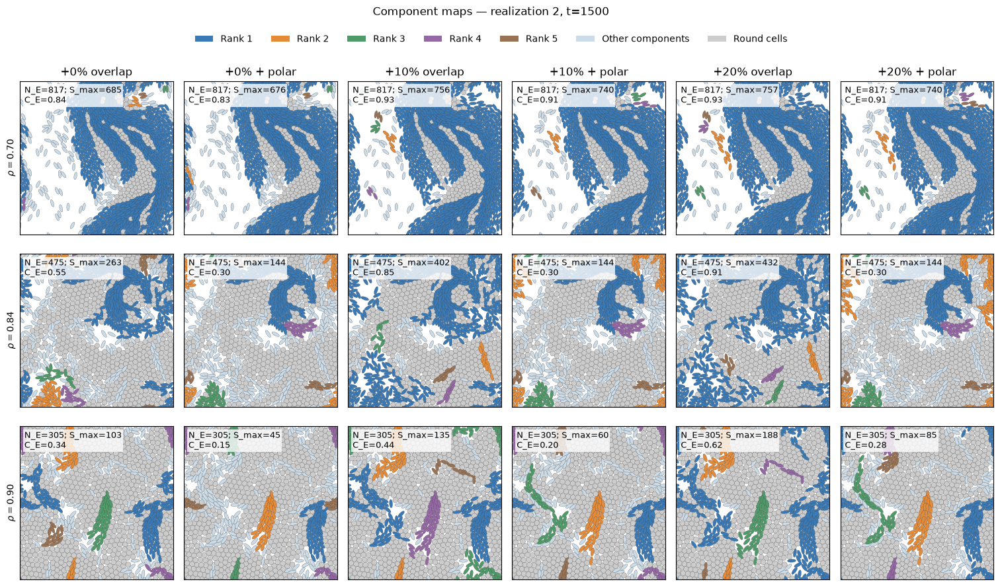

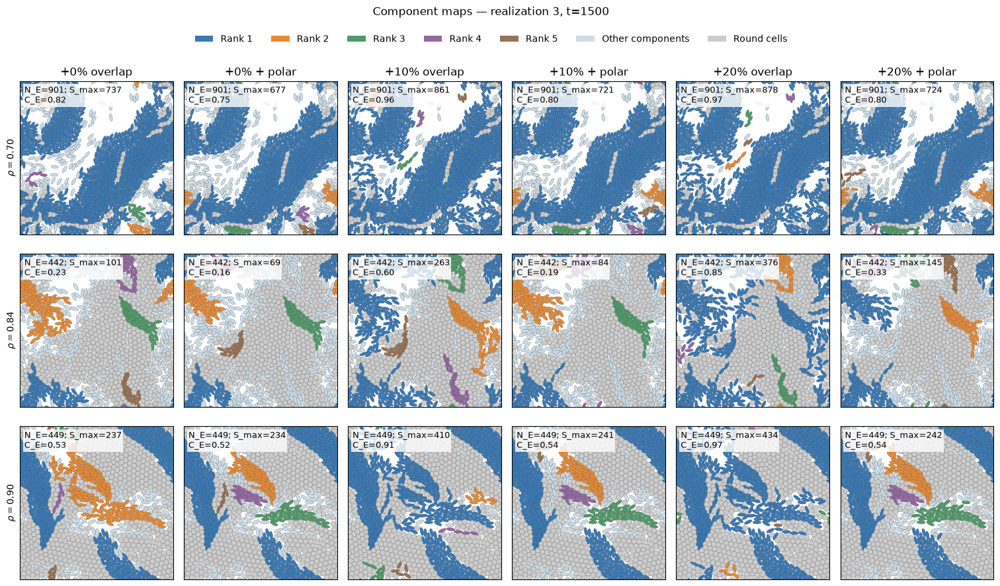

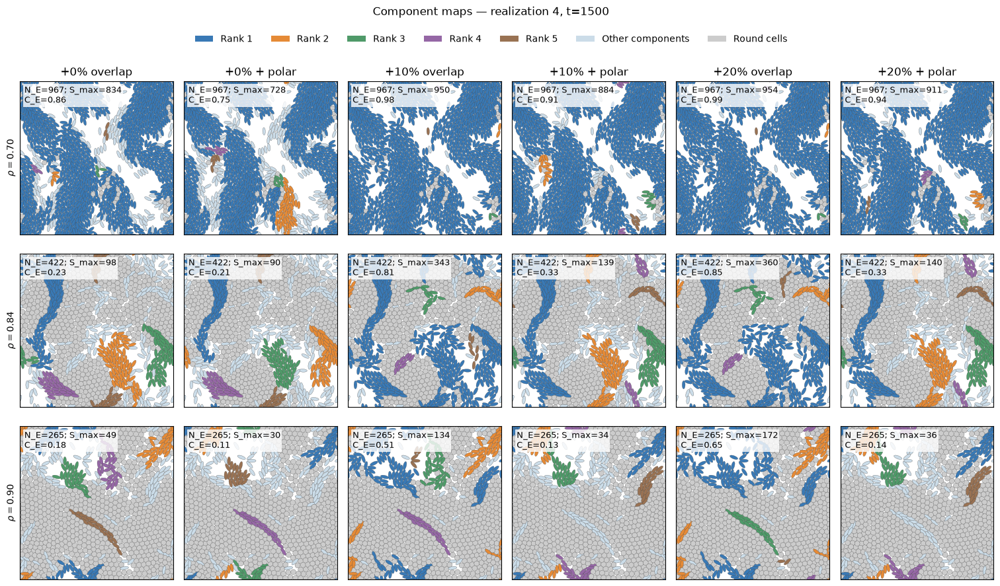

In [12]:
for realization,seed in enumerate(SEEDS,start=1):
    fig,axes=plt.subplots(len(MAP_DENSITIES),6,figsize=(19,10),squeeze=False)
    for row,rho in enumerate(MAP_DENSITIES):
        snapshot=read_snapshot(snapshot_paths[(LAMBDA_CORE,KAPPA,rho,seed,MAP_STEP)])
        records,labels=analyze_connectivity(snapshot,with_labels=True)
        for col,(factor,polar_filter) in enumerate(product(RANGE_FACTORS,(False,True))):
            lab=labels[(factor,polar_filter)]
            colors=component_facecolors(lab)
            record=next(r for r in records if r["range_factor"]==factor and r["polar_filter"]==polar_filter)
            note=f"N_E={record['n_elongated']}; S_max={record['largest_size']}\nC_E={record['C_E']:.2f}"
            draw_snapshot(axes[row,col],snapshot,facecolors=colors,annotation=note)
            if row==0:axes[row,col].set_title(f"+{100*(factor-1):.0f}%"+(" + polar" if polar_filter else " overlap"))
            if col==0:axes[row,col].set_ylabel(rf"$\rho={rho:.2f}$")
    fig.suptitle(f"Component maps — realization {realization}, t={MAP_STEP*DELTA_T:g}")
    handles=[Patch(facecolor=c,label=f"Rank {i+1}") for i,c in enumerate(COMPONENT_COLORS)]
    handles += [Patch(facecolor=SMALL_COMPONENT_COLOR,label="Other components"),Patch(facecolor=ROUND_COLOR,label="Round cells")]
    fig.legend(handles=handles,loc="upper center",bbox_to_anchor=(.5,.95),ncol=7,frameon=False)
    fig.subplots_adjust(top=.87,wspace=.07,hspace=.10)
    finish_figure(fig,f"08_component_maps_seed_{seed}")

## 8. Deformation diagnostics and exports

Event rates below count accepted events per cell per unit time. Rejection fractions use the summed attempts as denominator, avoiding an unweighted average of interval ratios. A window with no attempts has an undefined rejection fraction. These diagnostics help distinguish reduced deformation activity from a change in how elongates organize.

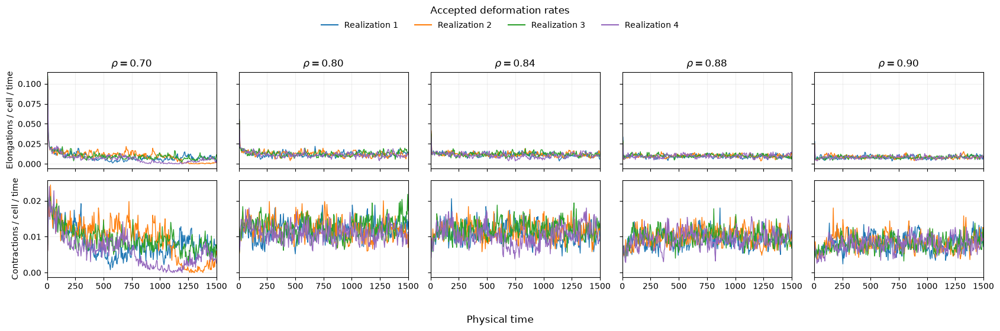

Figures: /home/usuario/Documentos/oncostreams/oncostreams_analysis_triangular/preliminar/kappa/refinement/figures
Tables: /home/usuario/Documentos/oncostreams/oncostreams_analysis_triangular/preliminar/kappa/refinement/analysis_tables


In [13]:
duration=deformation.number_of_steps*DELTA_T
for event in ["round_elongation_successes","contraction_events"]:
    deformation[event+"_rate"]=deformation[event]/(deformation.actual_N*duration)
time_panels(deformation,[("round_elongation_successes_rate","Elongations / cell / time"),
                          ("contraction_events_rate","Contractions / cell / time")],
            "09_deformation_rates","Accepted deformation rates")
event_windows=[]
for start,end in TIME_WINDOWS:
    part=deformation.loc[(deformation.time>start)&(deformation.time<=end)]
    result=part.groupby(RUN_KEYS,as_index=False)[["contraction_attempts","contraction_overlap_rejections","contraction_events","round_elongation_attempts","round_elongation_successes"]].sum()
    result["contraction_rejection_fraction"]=result.contraction_overlap_rejections/result.contraction_attempts.replace(0,np.nan)
    result["time_start"],result["time_end"]=start,end
    event_windows.append(result)
deformation_windows=pd.concat(event_windows,ignore_index=True)
for name,frame in [("validation",checks),("order_window_summary",order_windows),
                   ("connectivity_window_summary",connectivity_windows),("deformation_window_summary",deformation_windows)]:
    frame.to_parquet(TABLE_DIR/f"{name}.parquet",index=False)
settings.update(time_windows=TIME_WINDOWS,densities=DENSITIES,seeds=SEEDS,
                kappa=KAPPA,lambda_core=LAMBDA_CORE,xi_safe=XI_SAFE)
(TABLE_DIR/"analysis_settings.json").write_text(json.dumps(settings,indent=2))
print(f"Figures: {FIGURE_DIR.resolve()}\nTables: {TABLE_DIR.resolve()}")